In [1]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
#from collections import namedtuple
import math
import ast
from scipy.stats import chisquare
from scipy import special
from scipy.optimize import minimize
import seaborn as sns
sns.set_style("whitegrid")
import shapely as shapely
from shapely.geometry import LineString
from scipy.stats import crystalball
import scipy.special as sc
from iminuit import cost, Minuit
from numba_stats import crystalball, norm
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [2]:
def SingleEscapeSort(dataframe):
    dataframe = dataframe.drop('Unnamed: 0', axis=1)
    # if b==True:
    #     dataframe = dataframe.drop('10', axis=1)
    col = dataframe.pop("NTD")
    col2 = dataframe.pop('EnergyV')
    col3 = dataframe.pop('ChannelV')
    col4 = dataframe.pop('Neighbors')
    dataframe.insert(9, col2.name, col2)
    dataframe.insert(15, col.name, col)
    dataframe.insert(10, col3.name, col3)
    dataframe.insert(14, col4.name, col4)
    
    dataframe3 = dataframe[(dataframe['Multiplicity'] == 3)]
    dataframe3['EnergyV']=dataframe3['EnergyV'].apply(ast.literal_eval)
    dataframe3['ChannelV']=dataframe3['ChannelV'].apply(ast.literal_eval)
    dataframe3['NTD']=dataframe3['NTD'].apply(ast.literal_eval)
    dataframe3['Neighbors']=dataframe3['Neighbors'].apply(ast.literal_eval)
    
    rid3 = []
    dataframe3=dataframe3.reset_index(drop=True)
    for i in range(len(dataframe3)):
        if (2070<= dataframe3.iloc[i,9][2]< 2130):
            rid3.append(i)
            
    dataframe3_2100 = dataframe3[dataframe3.index.isin(rid3)]
    dataframe3_2100=dataframe3_2100.reset_index(drop=True)
    
    return dataframe3_2100

def NTD_Sort(dataframe_single):
    NTD_data = []
    no_NTD_data = []

    for i in range(len(dataframe_single)):
        if (dataframe_single.iloc[i,10][0] in dataframe_single.iloc[i,17]) or (dataframe_single.iloc[i,10][1] in dataframe_single.iloc[i,17]) or (dataframe_single.iloc[i,10][2] in dataframe_single.iloc[i,17]):
                NTD_data.append(i) 
        else:
            no_NTD_data.append(i) 

    NTD_dataframe = dataframe_single[dataframe_single.index.isin(NTD_data)]
    NTD_dataframe =NTD_dataframe.reset_index(drop=True)

    no_NTD_dataframe = dataframe_single[dataframe_single.index.isin(no_NTD_data)]
    no_NTD_dataframe=no_NTD_dataframe.reset_index(drop=True)
    
    return NTD_dataframe, no_NTD_dataframe

def Topology_Sort(no_NTD_data):
    FC = []
    CE = []
    NC = []
    FN = []
    NE = []
    FF = []
    CC = []
    EE = []
    NN = []
    FE = []
    O = []

    for i in range(len(no_NTD_data)):
        if no_NTD_data.iloc[i,14][0][0] + no_NTD_data.iloc[i,14][1][0] == 'CF' or no_NTD_data.iloc[i,14][0][0] + no_NTD_data.iloc[i,14][1][0] == 'FC':
            FC.append(i)
        elif no_NTD_data.iloc[i,14][0][0] + no_NTD_data.iloc[i,14][1][0] == 'CE' or no_NTD_data.iloc[i,14][0][0] + no_NTD_data.iloc[i,14][1][0] == 'EC':
            CE.append(i)
        elif no_NTD_data.iloc[i,14][0][0] + no_NTD_data.iloc[i,14][1][0] == 'NC' or no_NTD_data.iloc[i,14][0][0] + no_NTD_data.iloc[i,14][1][0] == 'CN':
            NC.append(i)
        elif no_NTD_data.iloc[i,14][0][0] + no_NTD_data.iloc[i,14][1][0] == 'FN' or no_NTD_data.iloc[i,14][0][0] + no_NTD_data.iloc[i,14][1][0] == 'NF':
            FN.append(i)
        elif no_NTD_data.iloc[i,14][0][0] + no_NTD_data.iloc[i,14][1][0] == 'NE' or no_NTD_data.iloc[i,14][0][0] + no_NTD_data.iloc[i,14][1][0] == 'EN':
            NE.append(i)
        elif no_NTD_data.iloc[i,14][0][0] + no_NTD_data.iloc[i,14][1][0] == 'FF':
            FF.append(i)
        elif no_NTD_data.iloc[i,14][0][0] + no_NTD_data.iloc[i,14][1][0] == 'CC':
            CC.append(i)
        elif no_NTD_data.iloc[i,14][0][0] + no_NTD_data.iloc[i,14][1][0] == 'EE':
            EE.append(i)
        elif no_NTD_data.iloc[i,14][0][0] + no_NTD_data.iloc[i,14][1][0] == 'NN':
            NN.append(i)
        elif no_NTD_data.iloc[i,14][0][0] + no_NTD_data.iloc[i,14][1][0] == 'FE' or no_NTD_data.iloc[i,14][0][0] + no_NTD_data.iloc[i,14][1][0] == 'EF':
            FE.append(i)
        else:
            O.append(i)

    FC = no_NTD_data[no_NTD_data.index.isin(FC)]
    CE = no_NTD_data[no_NTD_data.index.isin(CE)]
    NC = no_NTD_data[no_NTD_data.index.isin(NC)]
    FN = no_NTD_data[no_NTD_data.index.isin(FN)]
    NE = no_NTD_data[no_NTD_data.index.isin(NE)]
    FF = no_NTD_data[no_NTD_data.index.isin(FF)]
    CC = no_NTD_data[no_NTD_data.index.isin(CC)]
    EE = no_NTD_data[no_NTD_data.index.isin(EE)]
    NN = no_NTD_data[no_NTD_data.index.isin(NN)]
    FE = no_NTD_data[no_NTD_data.index.isin(FE)]

    FC =FC.reset_index(drop=True)
    CE =CE.reset_index(drop=True)
    NC =NC.reset_index(drop=True)
    FN =FN.reset_index(drop=True)
    NE =NE.reset_index(drop=True)
    FF =FF.reset_index(drop=True)
    CC =CC.reset_index(drop=True)
    EE =EE.reset_index(drop=True)
    NN =NN.reset_index(drop=True)
    FE =FE.reset_index(drop=True)
    return FC, CE, NC, FN, NE, FF, CC, EE, NN, FE, O

def PrimarySecondarySplit(dataframe_1tonne_double):
    total_2100 = []
    total_511 = []

    for i in range(len(dataframe_1tonne_double)):
        total_511.append(dataframe_1tonne_double.iloc[i,9][0] + dataframe_1tonne_double.iloc[i,9][1])
        total_2100.append(dataframe_1tonne_double.iloc[i,9][2])
        
    return np.asarray(total_2100), np.asarray(total_511)

In [3]:
def ChannelRemoval(dataframe):
    df = pd.read_csv('InvalidChannels/M3SE511_InvalidChannelList.csv', sep=',')
    datasetlist = np.arange(3801, 3829)

    # Create a dictionary mapping each dataset to its channel list
    channel_map = df.groupby('Dataset')['Channels'].apply(list).to_dict()

    channel = []

    # Loop through the filtered datasets in dataframe_single
    for i in datasetlist:
        # Get the channel list for the dataset from the pre-built dictionary
        channel_list = channel_map.get(i, [])
        
        # Filter only rows in dataframe_single where the 'Dataset' equals the current dataset
        relevant_rows = dataframe[dataframe['Dataset'] == i]
        
        # Check for channel matches using vectorized apply with any()
        matches = relevant_rows.index[
            relevant_rows.iloc[:, 10].apply(lambda x: any(ch in channel_list for ch in x))
        ].tolist()
        
        # Add matching indices to the channel list
        channel.extend(matches)
        
    dataframe_reduced = dataframe.drop(channel)
    dataframe_reduced=dataframe_reduced.reset_index(drop=True)
        
    return dataframe_reduced

In [4]:
dataframe = pd.read_csv('NTDs_2590_2625_q_tree_call-2tonne.csv', sep = ',', header=0)
dataframe_single = SingleEscapeSort(dataframe)


/var/folders/z8/n41n2zq134qgydj3s_285jqc0000gn/T/ipykernel_40215/38666838.py:1: DtypeWarning: Columns (27,28,29,30,31,32,33,34,35) have mixed types. Specify dtype option on import or set low_memory=False.
  dataframe = pd.read_csv('NTDs_2590_2625_q_tree_call-2tonne.csv', sep = ',', header=0)
/var/folders/z8/n41n2zq134qgydj3s_285jqc0000gn/T/ipykernel_40215/3158374240.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataframe3['EnergyV']=dataframe3['EnergyV'].apply(ast.literal_eval)
/var/folders/z8/n41n2zq134qgydj3s_285jqc0000gn/T/ipykernel_40215/3158374240.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentati

In [5]:
dataframe_reduced_single = ChannelRemoval(dataframe_single)

In [6]:
NTD_single, no_NTD_single = NTD_Sort(dataframe_reduced_single)
FC_NTD, CE_NTD, NC_NTD, FN_NTD, NE_NTD, FF_NTD, CC_NTD, EE_NTD, NN_NTD, FE_NTD, O_NTD = Topology_Sort(NTD_single)
FC, CE, NC, FN, NE, FF, CC, EE, NN, FE, O = Topology_Sort(no_NTD_single)

NTD_events = pd.concat([CE_NTD, NC_NTD, NE_NTD, CC_NTD, EE_NTD, NN_NTD])
NTD_2100, NTD_511 = PrimarySecondarySplit(NTD_events)

FCmerged = pd.concat([FC, FC_NTD])
FNmerged = pd.concat([FN, FN_NTD])
FFmerged = pd.concat([FF, FF_NTD])
FEmerged = pd.concat([FE, FE_NTD])

NonNTDevents = pd.concat([FC, FC_NTD, CE, NC, FN, FN_NTD, NE, FF, FF_NTD, CC, EE, NN, FE, FE_NTD])
NonNTD_2100, NonNTD_511 = PrimarySecondarySplit(NonNTDevents)

In [7]:
def NormGaussianExp(x,mu,sigma,b,C):
    E0 = min(x)
    E1 = max(x)
    return (1-b)*(norm.pdf(x,mu,sigma))+b*(np.exp(-C*x))/((1/C)*(np.exp(-E0*C)-np.exp(-E1*C)))

def Chi2(data, arr, bin_num):
    hist, bins = np.histogram(data, bin_num)
    bin_width = (max(data) - min(data))/bin_num

    bin_centers = (bins[:-1] + bins[1:]) / 2
    
    non_zero_indices = hist > 0
    filtered_hist = hist[non_zero_indices]
    filtered_bin_centers = bin_centers[non_zero_indices]

    fitted_pdf = NormGaussianExp(filtered_bin_centers, *arr)*len(data)*bin_width

    chi2 = np.sum((filtered_hist-fitted_pdf)**2/fitted_pdf)
    
    return chi2

def PValue(dof, chi2):
    return 1-(sc.gammainc(dof/2, chi2/2))

def Residual_Plot(data, arr, bin_num):
    hist, bins = np.histogram(data, bin_num)
    bin_width = (max(data) - min(data))/bin_num

    bin_centers = (bins[:-1] + bins[1:]) / 2
    
    non_zero_indices = hist > 0
    filtered_hist = hist[non_zero_indices]
    filtered_bin_centers = bin_centers[non_zero_indices]
        
    E0 = min(data)
    E1 = max(data)

    fitted_pdf = NormGaussianExp(filtered_bin_centers, *arr)*len(data)*bin_width
    
    return filtered_bin_centers, (filtered_hist - fitted_pdf)/np.sqrt(filtered_hist), np.sqrt(filtered_hist)

def Minimizer(data, title, initial_parms, bin_num):
    c = cost.UnbinnedNLL(data, NormGaussianExp)

    E0 = min(data)
    E1 = max(data)
    Ec = (E0+E1)/2
    bound_A = 1/(Ec-E0)

    m = Minuit(c,*initial_parms)
    m.limits["b"] = (0, 1)
    m.limits["mu", 'sigma'] = (0, None)
    m.migrad()
    m.hesse()

    x_values = np.linspace(min(data), max(data), 1000)
    bin_width = (max(data) - min(data))/bin_num

    fig = plt.figure()
    ax=fig.add_axes((.1,.3,.8,.6))
    
    props = dict(boxstyle='round', facecolor='whitesmoke', alpha=0.5)
    text = '\n'.join(( r'$\Delta\chi^2/ndf= $' + str(np.round(Chi2(data, m.values, bin_num), decimals=2)) +'/' +str(bin_num - (NormGaussianExp.__code__.co_argcount -1), ),
                    r'$P(ndf,\chi^2)=%.2f$' % (PValue(bin_num - (NormGaussianExp.__code__.co_argcount -1),Chi2(data, m.values, bin_num)), ),
        'Entries: ' + (str(len(data))),
        r'$\mu=$ ' + str(np.round(m.values[0], decimals = 2) ) + '+-'+ str(np.round(m.errors[0], decimals = 2) ),
        r'$\sigma=$ ' + str(np.round(m.values[1], decimals = 2) ) + '+-'+ str(np.round(m.errors[1], decimals = 2) ),
        r'$b=$ ' + str(np.format_float_scientific(m.values[2], precision = 2) ) + '+-'+ str(np.format_float_scientific(m.errors[2], precision = 2) ),
        r'$C=$ ' + str(np.format_float_scientific(m.values[3], precision = 2) ) + '+-'+ str(np.format_float_scientific(m.errors[3], precision = 2) )
        ))
    
    mu, sigma, b, C = m.values
    muerr, sigmaerr, berr,Cerr = m.errors

    ax.hist(data, bins = bin_num , histtype="step",fill=False);
    ax.plot(x_values, NormGaussianExp(x_values,*m.values)*len(data)*bin_width,label='Fitted PDF', color='#02383C')
    ax.plot(x_values, (1-b)*norm.pdf(x_values,mu, sigma)*len(data)*bin_width, label='Primary Gaussian', linestyle='--', color='#BD512F')
    ax.plot(x_values, b*(np.exp(-C*x_values))/((1/C)*(np.exp(-E0*C)-np.exp(-E1*C)))*len(data)*bin_width, label='Exp Bckg', linestyle='--', color='#615DEC')
    ax.legend(loc='upper right')
    ax.text(0.03, 0.95, text, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=props)
    ax.set_title(title)

    ax2=fig.add_axes((.1,.08,.8,.2))        
    ax2.errorbar(Residual_Plot(data, m.values, bin_num)[0],Residual_Plot(data, m.values, bin_num)[1], fmt='o',markersize=4)
    ax2.axhline(0, linestyle='--', color='crimson')
    
    return mu, muerr, sigma, sigmaerr, Chi2(data, m.values, bin_num)

def MinimizerTopologies(data, topologies, initial_parms, wid, height, figwidth, figheight):
    fitarr = []
    errorarr = []
    PDFs = []
    gauss = []
    Exp = []
    xvals = []
    bin_num = []
    bin_width = []

    for i in range(len(data)):
        E0 = min(data[i])
        E1 = max(data[i])
        c = cost.UnbinnedNLL(data[i], NormGaussianExp)
        m = Minuit(c,*initial_parms[i])
        m.limits["b"] = (0, 1)
        m.limits["mu",'sigma'] = (0, None)
        m.migrad()
        m.hesse()
        
        fitarr.append(m.values)
        errorarr.append(m.errors)
        x_values = np.linspace(min(data[i]), max(data[i]), 1000)
        xvals.append(x_values)
        bin_num.append(int(E1-E0))
        
        bin_width.append((E1-E0)/(int(E1-E0)))

    chisq = []
    pvals = []
    means = []
    sigmas = []
    b = []
    C = []

    meanserr = []
    sigmaserr = []
    berr = []
    Cerr = []
        
    for i in range(len(fitarr)):
        E0 = min(data[i])
        E1 = max(data[i])
        PDFs.append(NormGaussianExp(xvals[i],*fitarr[i])*len(data[i])*bin_width[i])
        gauss.append((1-fitarr[i][2])*norm.pdf(xvals[i],fitarr[i][0], fitarr[i][1])*len(data[i])*bin_width[i])
        Exp.append(fitarr[i][2]*(np.exp(-fitarr[i][3]*xvals[i]))/((1/fitarr[i][3])*(np.exp(-E0*fitarr[i][3])-np.exp(-E1*fitarr[i][3])))*len(data[i])*bin_width[i])
        chisq.append(Chi2(data[i], fitarr[i], bin_num[i]))
        pvals.append(PValue(bin_num[i]-(NormGaussianExp.__code__.co_argcount -1), chisq[i]))
        
        means.append(fitarr[i][0])
        sigmas.append(fitarr[i][1])
        b.append(fitarr[i][2])
        C.append(fitarr[i][3])
        
        meanserr.append(errorarr[i][0])
        sigmaserr.append(errorarr[i][1])
        berr.append(errorarr[i][2])
        Cerr.append(errorarr[i][3])
        
        
        
    data = { 'Topologies': topologies,
        'Bin Num': bin_num,
    'Histogram Data': data,
        'X-axis': xvals,
        'Fit': PDFs,
        'gauss': gauss,
        'Exp': Exp,
        'Means': means,
        'Sigmas': sigmas,
        'b': b,
        'C': C, 
        'Chi2': chisq,
        'p-value': pvals, 
        'Meanserr': meanserr,
        'Sigmaserr': sigmaserr,
        'berr': berr,
        'Cerr': Cerr,}

    df = pd.DataFrame(data)
        
    fig, axs = plt.subplots(wid, height, figsize=(figwidth, figheight))
    props = dict(boxstyle='round', facecolor='whitesmoke')
    for i, ax in enumerate(axs.flatten()):
        if i < len(df):
            divider = make_axes_locatable(ax)
            
            text = '\n'.join(( r'$\Delta\chi^2/ndf= $' + str(np.round(df['Chi2'][i], decimals=2)) +'/' +str(df['Bin Num'][i] - (NormGaussianExp.__code__.co_argcount -1), ),
                    r'$P(ndf,\chi^2)=%.2f$' % (df['p-value'][i], ),
        'Entries: ' + (str(len(df['Histogram Data'][i]))),
        r'$\mu=$ ' + str(np.round(df['Means'][i], decimals = 2) ) + '+-'+ str(np.round(df['Meanserr'][i], decimals = 2) ),
        r'$\sigma=$ ' + str(np.round(df['Sigmas'][i], decimals = 2) ) + '+-'+ str(np.round(df['Sigmaserr'][i], decimals = 2) ),
        r'$b=$ ' + str(np.format_float_scientific(df['b'][i], precision = 2) ) + '+-'+ str(np.format_float_scientific(df['berr'][i], precision = 2) ),
        r'$C=$ ' + str(np.format_float_scientific(df['C'][i], precision = 2) ) + '+-'+ str(np.format_float_scientific(df['Cerr'][i], precision = 2) )
        ))
            
            ax.text(0.03, 0.95, text, transform=ax.transAxes, fontsize=8, verticalalignment='top', bbox=props)
            
            ax.hist(df['Histogram Data'][i], bins=df['Bin Num'][i], histtype="step")
            ax.plot(df['X-axis'][i], df['Fit'][i], label='Fitted PDF', color='#02383C')
            ax.plot(df['X-axis'][i], df['gauss'][i], label='Gaussian', linestyle='--', color='#BD512F')
            ax.plot(df['X-axis'][i], df['Exp'][i], label='Exp Background', linestyle='--', color='#615DEC')
            ax.set_title(df["Topologies"][i])
            ax.legend(loc='upper right')
            
            ax2 = divider.append_axes("bottom", size="30%", pad=0.05)
            ax.figure.add_axes(ax2)
            ax2.errorbar(Residual_Plot(df['Histogram Data'][i], fitarr[i], bin_num[i])[0],Residual_Plot(df['Histogram Data'][i], fitarr[i], bin_num[i])[1], fmt='o',markersize=4)
            ax2.axhline(0, linestyle='--', color='crimson')
            
    plt.tight_layout()
    plt.show()
    
    return df

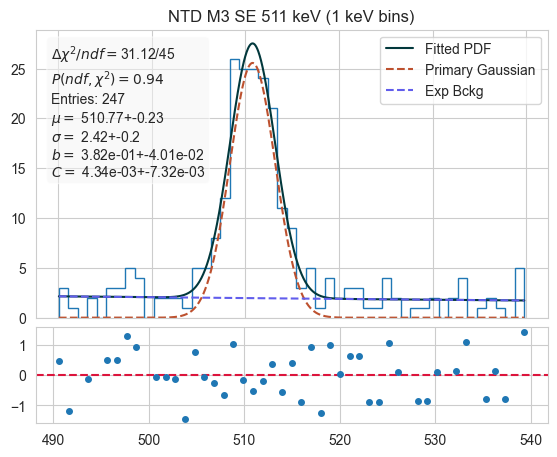

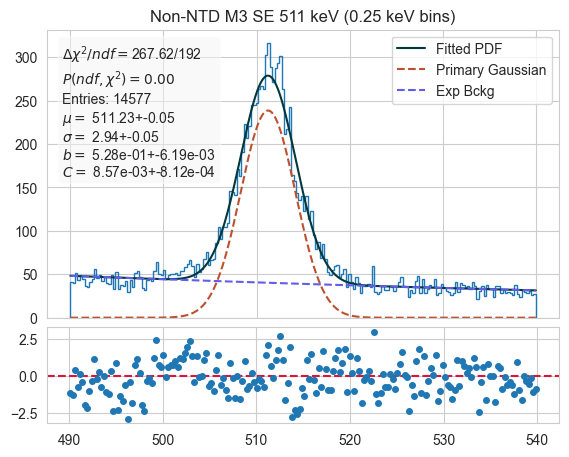

In [ ]:
data = [i for i in NTD_511 if 490 <= i <= 540]
NTDmu, NTDmu_err, NTDsigma, NTDsigmaerr, NTDchi2 = Minimizer(data, 'NTD M2 SE 511 keV (1 keV bins)', [511, 2.3, 0.11, 6.89713150e-03], int(max(data)-min(data)))

dataNonNTD = [i for i in NonNTD_511 if 490 <= i <= 540]
nonNTDmu, nonNTDmu_err, nonNTDsigma, nonNTDsigmaerr, nonNTDchi2 = Minimizer(dataNonNTD, 'Non-NTD M2 SE 511 keV (0.25 keV bins)', [511, 2.3, 0.11, 6.89713150e-03], 4*int(max(dataNonNTD)-min(dataNonNTD)))

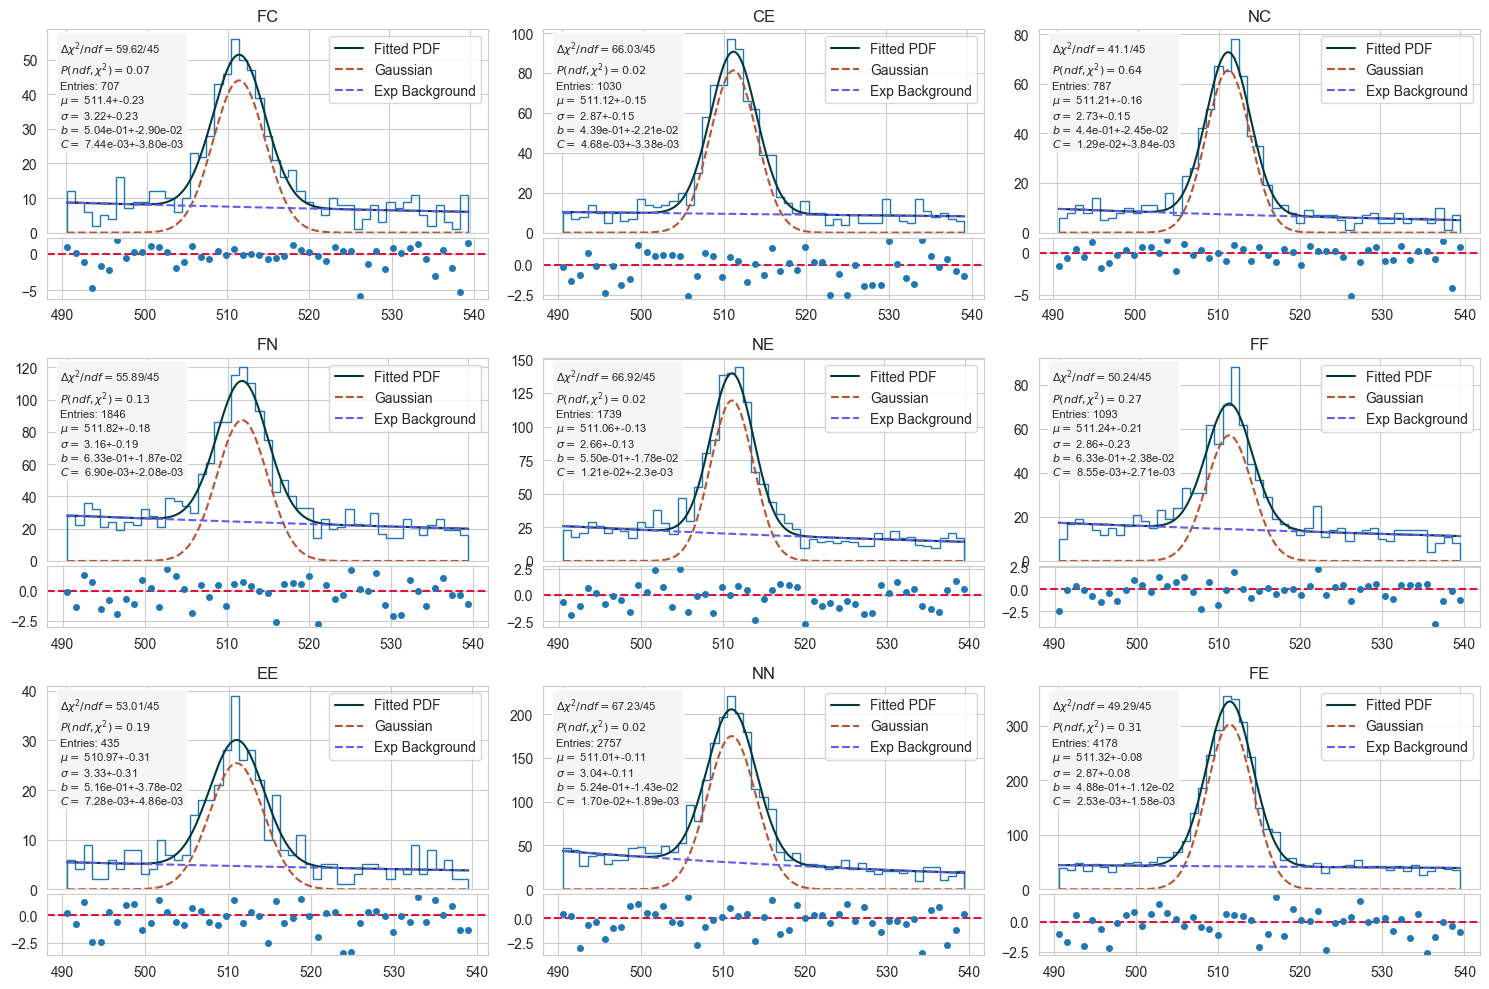

In [9]:
FC_511_cut, FC_511 = PrimarySecondarySplit(FCmerged)
CE_511_cut, CE_511 = PrimarySecondarySplit(CE)
NC_511_cut, NC_511 = PrimarySecondarySplit(NC)
FN_511_cut, FN_511 = PrimarySecondarySplit(FNmerged)
NE_511_cut, NE_511 = PrimarySecondarySplit(NE)
FF_511_cut, FF_511 = PrimarySecondarySplit(FFmerged)
# CC_511_cut, CC_511 = PrimarySecondarySplit(CC) not enough events to fit anything
EE_511_cut, EE_511 = PrimarySecondarySplit(EE)
NN_511_cut, NN_511 = PrimarySecondarySplit(NN)
FE_511_cut, FE_511 = PrimarySecondarySplit(FEmerged)

FC_511_cut = [i for i in FC_511 if 490 <= i <= 540]
CE_511_cut = [i for i in CE_511 if 490 <= i <= 540]
NC_511_cut = [i for i in NC_511 if 490 <= i <= 540]
FN_511_cut = [i for i in FN_511 if 490 <= i <= 540]
NE_511_cut = [i for i in NE_511 if 490 <= i <= 540]
FF_511_cut = [i for i in FF_511 if 490 <= i <= 540]
EE_511_cut = [i for i in EE_511 if 490 <= i <= 540]
NN_511_cut = [i for i in NN_511 if 490 <= i <= 540]
FE_511_cut = [i for i in FE_511 if 490 <= i <= 540]

FC_initial_511 = [5.11200577e+02, 3.03369145e+00, 0.5, 7.55802068e-03]
CE_initial_511 = [5.11018269e+02, 2.81020118e+00, 0.5,5.87756146e-03]
NC_initial_511 = [5.11182419e+02, 2.78208147e+00, 0.5, 1.27697351e-02]
FN_initial_511 = [5.11850438e+02, 2.92269445e+00, 0.5,6.89676842e-03]
NE_initial_511 = [5.11029528e+02, 2.58916615e+00,  0.5, 1.28240231e-02]
FF_initial_511 = [5.11469486e+02, 2.69210304e+00,  0.5, 6.42837798e-03]
EE_initial_511 = [5.10857992e+02, 3.17146179e+00,  0.5, 8.35769289e-03]
NN_initial_511 = [5.10889791e+02, 2.94974151e+00,  0.5,1.63421618e-02]
FE_initial_511 = [5.11249583e+02, 2.83977420e+00, 0.5, 2.96274049e-03]

hist_data = [FC_511_cut, CE_511_cut, NC_511_cut, FN_511_cut, NE_511_cut, FF_511_cut, EE_511_cut, NN_511_cut, FE_511_cut]
initial_parms = [FC_initial_511, CE_initial_511, NC_initial_511, FN_initial_511, NE_initial_511, FF_initial_511, EE_initial_511, NN_initial_511, FE_initial_511]
topologies = ['FC', 'CE', 'NC', 'FN', 'NE', 'FF', 'EE', 'NN', 'FE']

df = MinimizerTopologies(hist_data, topologies, initial_parms, 3,3, 15, 10)

In [10]:
def ExpectedVals(total_dataframe, dataframe):
        weights = [(((len(total_dataframe[total_dataframe['Dataset']==3801]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3801]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3802]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3802]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3803]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3803]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3804]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3804]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3805]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3805]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3806]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3806]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3807]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3807]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3808]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3808]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3809]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3809]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3810]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3810]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3811]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3811]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3812]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3812]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3813]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3813]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3814]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3814]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3815]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3815]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3816]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3816]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3817]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3817]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3818]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3818]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3819]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3819]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3820]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3820]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3821]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3821]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3822]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3822]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3823]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3823]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3824]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3824]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3825]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3825]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3826]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3826]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3827]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3827]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3828]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3828]))/len(dataframe))*100),
                   ]
        
        df_bias = pd.read_csv('Dataset-Info-ResBias/M3SE511_bias_all.txt', sep=',', names=['Dataset', 'Bias', 'Bias_err'], header=None)
        df_res = pd.read_csv('Dataset-Info-ResBias/M3SE511_reso_all.txt', sep=',', names=['Dataset', 'Res', 'Res_err'], header=None)
        
        mean_bias = 0
        sigma_res = 0
        
        for i in range(len(weights)):
                mean_bias += weights[i]*df_bias.iloc[i+1,1]
                sigma_res += weights[i]*df_res.iloc[i+1,1]
                
        average_means_bias = mean_bias/sum(weights)
        average_sigma_res = sigma_res/sum(weights)
        
        mean_bias_err = 0
        sigma_res_err = 0
        
        for i in range(len(weights)):
                mean_bias_err += (weights[i]*df_bias.iloc[i+1,2])**2
                sigma_res_err += (weights[i]*df_res.iloc[i+1,2])**2
        
        actual_mean_err = 1/sum(weights)*np.sqrt(mean_bias_err)
        actual_sigma_err = 1/sum(weights)*np.sqrt(sigma_res_err)
        
        
        return average_means_bias, (average_sigma_res/2.355), actual_mean_err, actual_sigma_err*(1/2.355)

In [11]:
mean_bias, sigma, meanerr, sigmaerr = ExpectedVals(dataframe_reduced_single, dataframe_reduced_single)

Text(0.5, 1.0, 'M3 SE 511 keV Standard Devs')

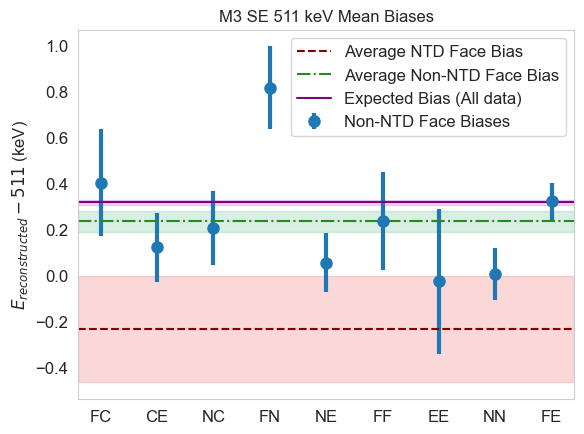

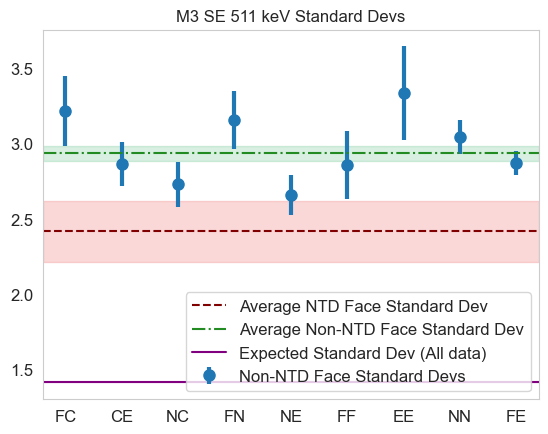

In [12]:
plt.figure()
plt.errorbar(topologies, df['Means']-511, yerr=df['Meanserr'], ms=8, elinewidth=3, fmt='o', label='Non-NTD Face Biases')
# plt.errorbar(xNonNTD-0.13, topologymeans, yerr=asymmetric_errormu, ms=8, elinewidth=3, fmt='o', label='Non-NTD Face Means')
# plt.errorbar(xNTD+0.13, NTDmeans, yerr=ass_errNTD, fmt='s',ms=8, elinewidth=3, color='darkblue', label='NTD Face Means')

plt.axhspan(NTDmu-511 - NTDmu_err, NTDmu-511 + NTDmu_err, color='lightcoral', alpha=0.3)
plt.axhline(NTDmu-511, color='maroon', linestyle='--', label='Average NTD Face Bias')

plt.axhspan(nonNTDmu-511-nonNTDmu_err, nonNTDmu-511+nonNTDmu_err, color='mediumseagreen', alpha=0.2)
plt.axhline(nonNTDmu-511, color='forestgreen', linestyle='-.', label='Average Non-NTD Face Bias')

plt.axhspan(mean_bias + meanerr, mean_bias - meanerr, color='orchid', alpha=0.3)
plt.axhline(mean_bias, color='purple', linestyle='-', label='Expected Bias (All data)')

plt.legend(fontsize=12)

plt.xticks(np.arange(len(topologies)), topologies, fontsize=12);
plt.yticks(fontsize=12);
plt.grid(False)
plt.title('M3 SE 511 keV Mean Biases')
plt.ylabel(r'$E_{reconstructed}-511$ (keV)', fontsize=12)

plt.figure()
plt.errorbar(topologies, df['Sigmas'], yerr=df['Sigmaserr'], ms=8, elinewidth=3, fmt='o', label='Non-NTD Face Standard Devs')
# plt.errorbar(xNonNTD-0.13, topologymeans, yerr=asymmetric_errormu, ms=8, elinewidth=3, fmt='o', label='Non-NTD Face Means')
# plt.errorbar(xNTD+0.13, NTDmeans, yerr=ass_errNTD, fmt='s',ms=8, elinewidth=3, color='darkblue', label='NTD Face Means')

plt.axhspan(NTDsigma + NTDsigmaerr, NTDsigma - NTDsigmaerr, color='lightcoral', alpha=0.3)
plt.axhline(NTDsigma, color='maroon', linestyle='--', label='Average NTD Face Standard Dev')

plt.axhspan(nonNTDsigma-nonNTDsigmaerr, nonNTDsigma+nonNTDsigmaerr, color='mediumseagreen', alpha=0.2)
plt.axhline(nonNTDsigma, color='forestgreen', linestyle='-.', label='Average Non-NTD Face Standard Dev')

plt.axhspan(sigma + sigmaerr, sigma - sigmaerr, color='orchid', alpha=0.3)
plt.axhline(sigma, color='purple', linestyle='-', label='Expected Standard Dev (All data)')

plt.legend(fontsize=12,loc='lower right')

plt.xticks(np.arange(len(topologies)), topologies, fontsize=12);
plt.yticks(fontsize=12);
plt.grid(False)
plt.title('M3 SE 511 keV Standard Devs')

In [13]:
# for i in range(len(df['Means'])):
#     print(str(topologies[i])+' '+str(df['Means'][i]-511) + '+-' + str(df['Meanserr'][i]))
    
    
for i in range(len(df['Sigmas'])):
    print(str(topologies[i])+' '+str(df['Sigmas'][i]) + '+-' + str(df['Sigmaserr'][i]))

FC 3.218912270011625+-0.23151713484974779
CE 2.865050231323806+-0.14772845006582802
NC 2.7305113330900452+-0.14961985819097
FN 3.157129975672043+-0.19041649367509472
NE 2.6610810828992477+-0.13411545791447455
FF 2.8601492882054718+-0.22689952866093943
EE 3.334513839487885+-0.31190162994144544
NN 3.044527266310416+-0.11005876910128731
FE 2.871581477262475+-0.07745940708581389


In [14]:
print(mean_bias)
print(meanerr)
print(sigma)
print(sigmaerr)

0.31657142857142845
0.009582083621562286
1.4129355474673946
0.00021910538772246886
